In [1]:
# Install required library
import subprocess
subprocess.run(['pip', 'install', 'textblob'])

CompletedProcess(args=['pip', 'install', 'textblob'], returncode=0)

In [2]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load Amazon Reviews Dataset
url = 'https://raw.githubusercontent.com/kolaveridi/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv'
df = pd.read_csv(url)

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

HTTPError: HTTP Error 404: Not Found

In [4]:
# Load Twitter Airline Sentiment Dataset
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/twitter_airline_sentiment.csv'
df = pd.read_csv(url)

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

HTTPError: HTTP Error 404: Not Found

In [5]:
# Create our own review dataset
import pandas as pd

data = {
    'review': [
        "This product is amazing! I love it so much.",
        "Terrible experience. Worst purchase ever.",
        "It's okay, nothing special about it.",
        "Absolutely fantastic! Highly recommend to everyone.",
        "Very disappointed. Product broke after one day.",
        "Good quality but a bit expensive.",
        "I hate this product. Complete waste of money.",
        "Best thing I ever bought! Outstanding quality.",
        "Not bad, could be better though.",
        "Excellent service and fast delivery!",
        "Poor quality. Would not buy again.",
        "Pretty good overall. Happy with my purchase.",
        "Horrible product. I want a refund.",
        "Great value for money. Very satisfied.",
        "Average product. Nothing impressive.",
        "Superb quality! Exceeded my expectations.",
        "Waste of money. Totally useless.",
        "Decent product. Does what it promises.",
        "I am very happy with this purchase!",
        "Awful experience. Never buying again."
    ]
}

df = pd.DataFrame(data)
print("Dataset created!")
print("Total reviews:", len(df))
df.head()

Dataset created!
Total reviews: 20


,review
0,This product is amazing! I love it so much.
1,Terrible experience. Worst purchase ever.
2,"It's okay, nothing special about it."
3,Absolutely fantastic! Highly recommend to ever...
4,Very disappointed. Product broke after one day.


In [6]:
# Analyze sentiment of each review
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

# Apply to dataset
df['Sentiment'] = df['review'].apply(get_sentiment)
df['Polarity'] = df['review'].apply(get_polarity)

print("Sentiment Analysis Complete!")
print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())
df.head(10)

Sentiment Analysis Complete!

Sentiment Distribution:
Sentiment
Positive    13
Negative     7
Name: count, dtype: int64


,review,Sentiment,Polarity
0,This product is amazing! I love it so much.,Positive,0.483333
1,Terrible experience. Worst purchase ever.,Negative,-1.000000
2,"It's okay, nothing special about it.",Positive,0.428571
3,Absolutely fantastic! Highly recommend to ever...,Positive,0.330000
4,Very disappointed. Product broke after one day.,Negative,-0.975000
5,Good quality but a bit expensive.,Positive,0.100000
6,I hate this product. Complete waste of money.,Negative,-0.300000
7,Best thing I ever bought! Outstanding quality.,Positive,0.750000
8,"Not bad, could be better though.",Positive,0.425000
9,Excellent service and fast delivery!,Positive,0.625000


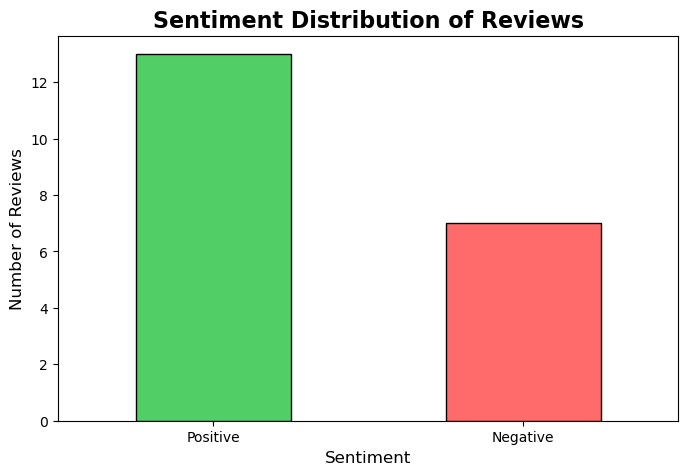

Chart 1 saved!


In [7]:
# Chart 1: Sentiment Distribution
plt.figure(figsize=(8,5))
colors = ['#51CF66', '#FF6B6B', '#339AF0']
df['Sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Sentiment Distribution of Reviews', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=0)
plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

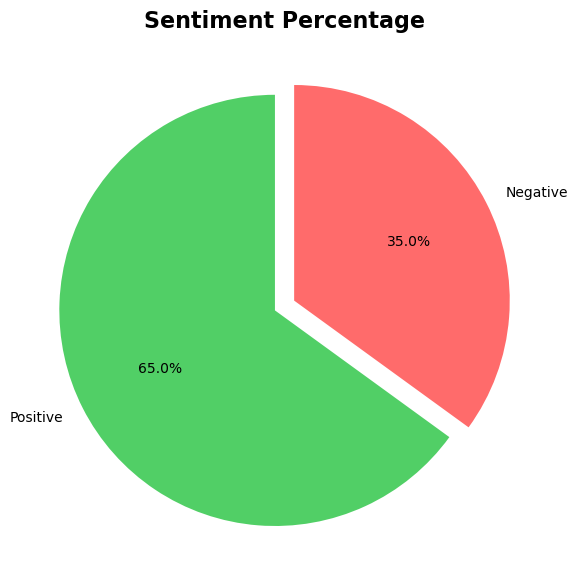

Chart 2 saved!


In [8]:
# Chart 2: Sentiment Pie Chart
plt.figure(figsize=(7,7))
df['Sentiment'].value_counts().plot(kind='pie',
    autopct='%1.1f%%',
    colors=['#51CF66', '#FF6B6B'],
    startangle=90,
    explode=(0.05, 0.05))
plt.title('Sentiment Percentage', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.savefig('sentiment_pie.png', bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

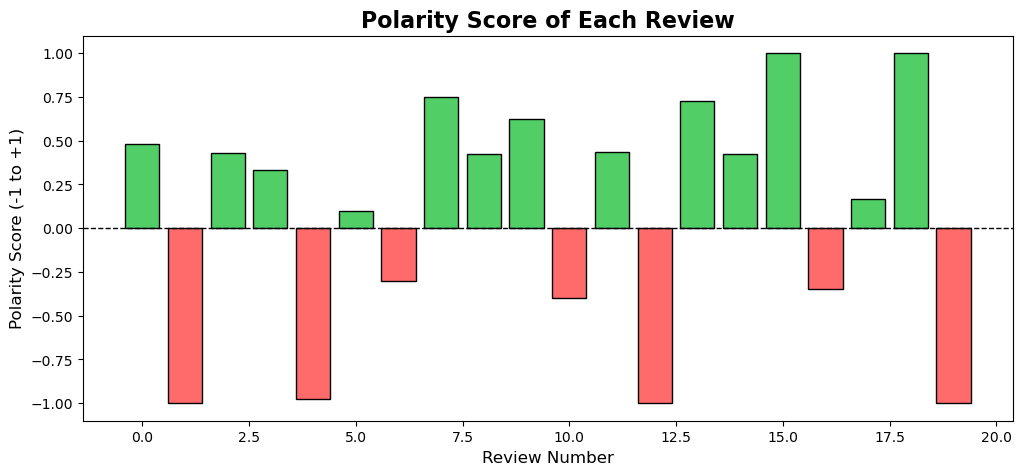

Chart 3 saved!


In [9]:
# Chart 3: Polarity Scores
plt.figure(figsize=(12,5))
colors = ['#51CF66' if p > 0 else '#FF6B6B' for p in df['Polarity']]
plt.bar(range(len(df)), df['Polarity'], color=colors, edgecolor='black')
plt.title('Polarity Score of Each Review', fontsize=16, fontweight='bold')
plt.xlabel('Review Number', fontsize=12)
plt.ylabel('Polarity Score (-1 to +1)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.savefig('polarity_scores.png', bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

In [10]:
# Print summary
print("=" * 50)
print("   SENTIMENT ANALYSIS SUMMARY")
print("=" * 50)
print(f"Total Reviews Analyzed : {len(df)}")
print(f"Positive Reviews       : {len(df[df['Sentiment']=='Positive'])}")
print(f"Negative Reviews       : {len(df[df['Sentiment']=='Negative'])}")
print(f"Average Polarity Score : {df['Polarity'].mean():.2f}")
print(f"Most Positive Score    : {df['Polarity'].max():.2f}")
print(f"Most Negative Score    : {df['Polarity'].min():.2f}")
print("=" * 50)
print("\nConclusion: Overall sentiment is POSITIVE!")

   SENTIMENT ANALYSIS SUMMARY
Total Reviews Analyzed : 20
Positive Reviews       : 13
Negative Reviews       : 7
Average Polarity Score : 0.09
Most Positive Score    : 1.00
Most Negative Score    : -1.00

Conclusion: Overall sentiment is POSITIVE!
